In [14]:
# License: BSD
# Author: Sasank Chilamkurthy

import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()   # interactive mode

In [15]:
# Data augmentation and normalization for training
# Just normalization for validation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

data_dir = 'tree'

splits = ['train', 'val', 'test']

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                                          data_transforms[x])
                  for x in splits}

dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=32,
                                             shuffle=(x == 'train'), num_workers=4)
              for x in splits}

dataset_sizes = {x: len(image_datasets[x]) for x in splits}
class_names = image_datasets['train'].classes

# We want to be able to train our model on an `accelerator <https://pytorch.org/docs/stable/torch.html#accelerators>`__
# such as CUDA, MPS, MTIA, or XPU. If the current accelerator is available, we will use it. Otherwise, we use the CPU.

device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")
print(f"Löytyi {len(class_names)} luokkaa.")

Using cpu device
Löytyi 23 luokkaa.


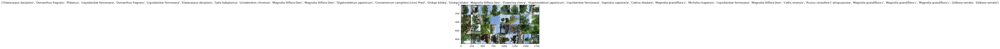

In [16]:
def imshow(inp, title=None):
    """Display image for Tensor."""
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)  # pause a bit so that plots are updated


# Get a batch of training data
inputs, classes = next(iter(dataloaders['train']))

# Make a grid from batch
out = torchvision.utils.make_grid(inputs)

imshow(out, title=[class_names[x] for x in classes])

In [17]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dict(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch}/{num_epochs - 1}')
            print('-' * 10)

            # Opetus ja validointi pidetään erillään
            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()  # Set model to training mode
                else:
                    model.eval()   # Set model to evaluate mode

                running_loss = 0.0
                running_corrects = 0

                # Iterate over data.
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # zero the parameter gradients
                    optimizer.zero_grad()

                    # forward
                    # track history if only in train
                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        # backward + optimize only if in training phase
                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    # statistics
                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

                # deep copy the model
                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # load best model weights
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

In [41]:
import math

def visualize_model(model, num_images=23, split='val'):
    was_training = model.training
    model.eval()
    images_so_far = 0

    # Laitetaan kuvat 5 sarakkeeseen (23 kuvalle tulee 5 riviä)
    cols = 5
    rows = math.ceil(num_images / cols)

    # Luodaan tarpeeksi suuri ikkuna kaikille kuville
    fig = plt.figure(figsize=(15, 3 * rows))

    # Mean ja std kuvan palauttamiseksi normaaliksi
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])

    with torch.no_grad():
        # Mahdollistaa 'val'- tai 'test'-setin visualisoinnin
        for i, (inputs, labels) in enumerate(dataloaders[split]):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(rows, cols, images_so_far)
                ax.axis('off')
                ax.set_title(f'pred: {class_names[preds[j]]}', fontsize=10)

                # Kuvan un-normalisointi ja piirto suoraan ruutuun
                inp = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                inp = std * inp + mean
                inp = np.clip(inp, 0, 1)
                ax.imshow(inp)

                #.imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    plt.tight_layout()  # Asettelee kaikki 23 kuvaa tasakokoisiksi
                    plt.show()
                    model.train(mode=was_training)
                    return
                    
        plt.tight_layout()
        plt.show()
        model.train(mode=was_training)

In [19]:
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features

# Dynamisoitu 23 luokalle (len(class_names))
model_ft.fc = nn.Linear(num_ftrs, len(class_names))

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

# Kaikki painot auki oppimista varten
optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

# Oppimisnopeuden pudotus 7 kierroksen välein
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

In [20]:
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,
                       num_epochs=10)

Epoch 0/9
----------
train Loss: 2.6783 Acc: 0.2392
val Loss: 1.8309 Acc: 0.5145

Epoch 1/9
----------
train Loss: 1.6525 Acc: 0.5405
val Loss: 1.0653 Acc: 0.7116

Epoch 2/9
----------
train Loss: 1.1872 Acc: 0.6725
val Loss: 0.7531 Acc: 0.7988

Epoch 3/9
----------
train Loss: 0.9476 Acc: 0.7306
val Loss: 0.6435 Acc: 0.7863

Epoch 4/9
----------
train Loss: 0.8107 Acc: 0.7681
val Loss: 0.4995 Acc: 0.8527

Epoch 5/9
----------
train Loss: 0.7099 Acc: 0.7958
val Loss: 0.4312 Acc: 0.8817

Epoch 6/9
----------
train Loss: 0.6411 Acc: 0.8221
val Loss: 0.3632 Acc: 0.8942

Epoch 7/9
----------
train Loss: 0.5452 Acc: 0.8436
val Loss: 0.3253 Acc: 0.9108

Epoch 8/9
----------
train Loss: 0.5222 Acc: 0.8548
val Loss: 0.3166 Acc: 0.9066

Epoch 9/9
----------
train Loss: 0.5041 Acc: 0.8660
val Loss: 0.3215 Acc: 0.9108

Training complete in 202m 43s
Best val Acc: 0.910788


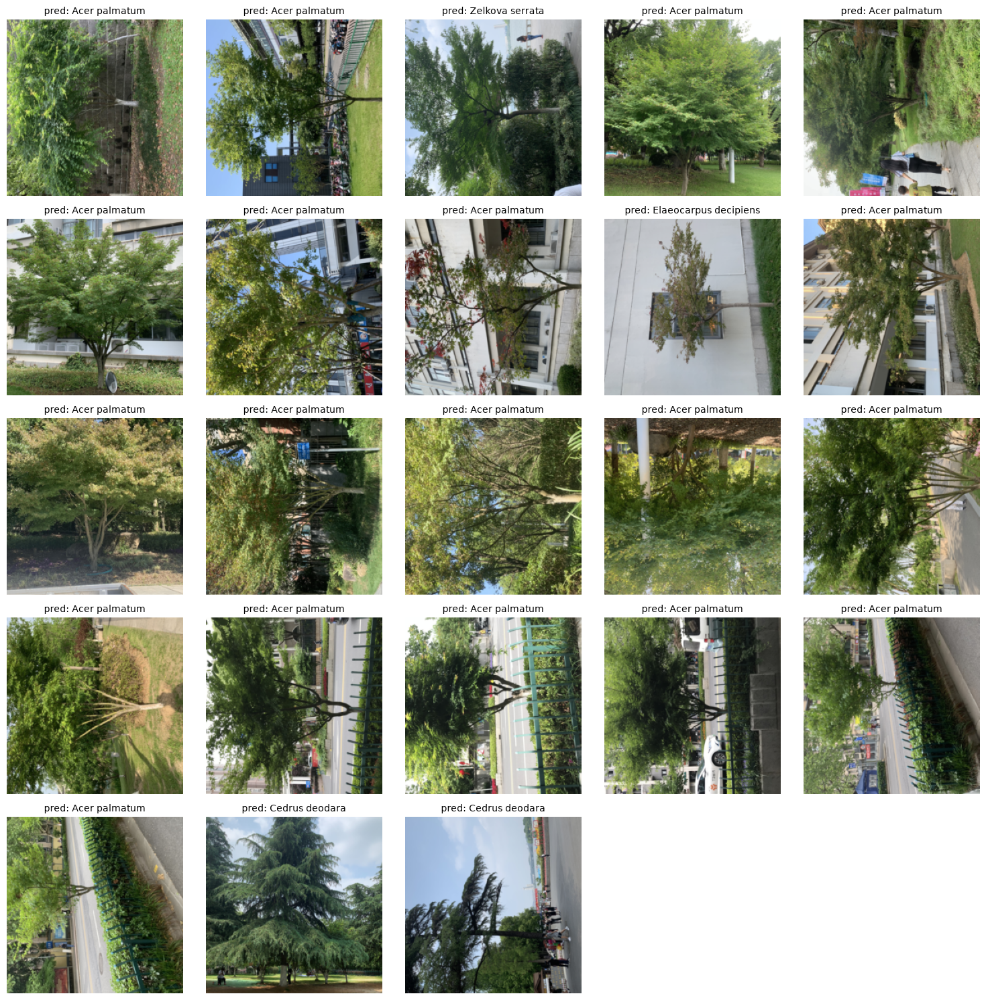

In [42]:
visualize_model(model_ft, num_images=23, split='val')

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x000002455D3F5120>
Traceback (most recent call last):
  File "c:\Users\OMISTAJA\anaconda3\envs\SolutionsInPR\Lib\site-packages\torch\utils\data\dataloader.py", line 1706, in __del__
    self._shutdown_workers()
  File "c:\Users\OMISTAJA\anaconda3\envs\SolutionsInPR\Lib\site-packages\torch\utils\data\dataloader.py", line 1650, in _shutdown_workers
    if self._persistent_workers or self._workers_status[worker_id]:
AttributeError: '_MultiProcessingDataLoaderIter' object has no attribute '_workers_status'


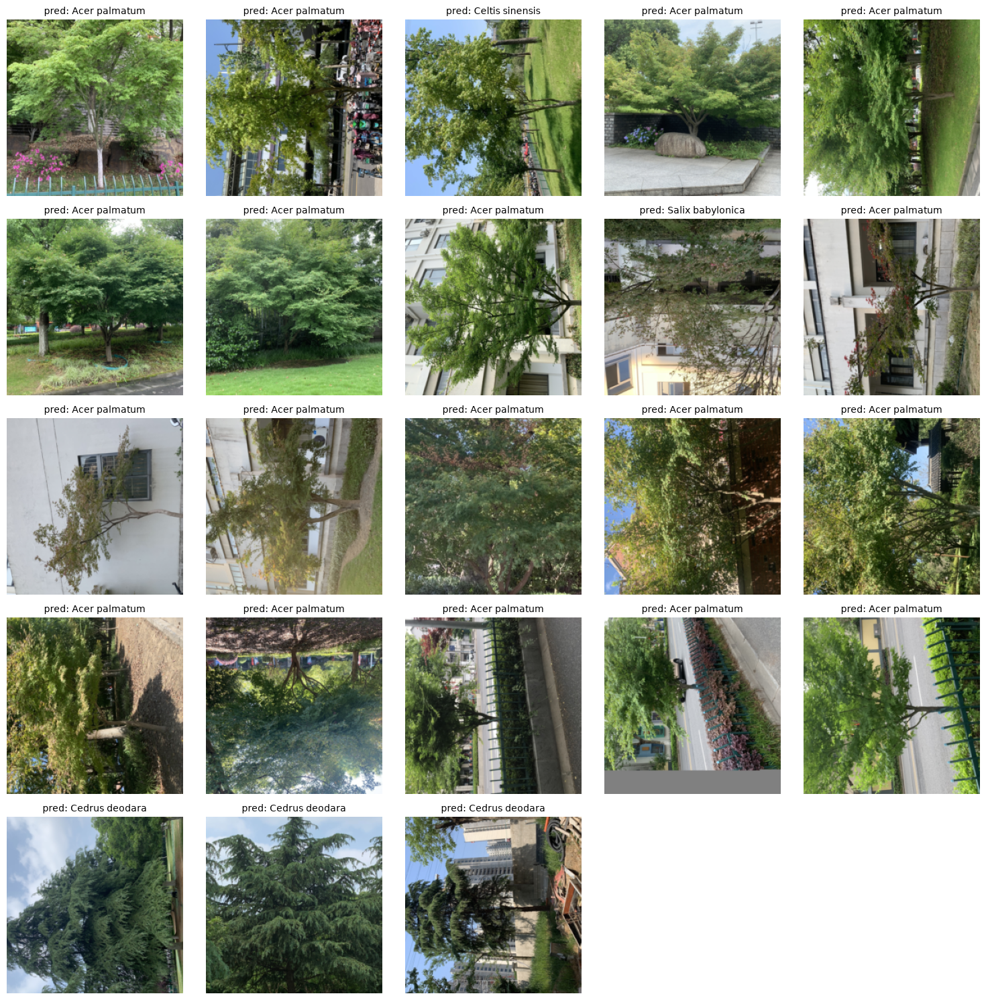

In [43]:
visualize_model(model_ft, num_images=23, split='test')

In [22]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

# Uusi kerros heittää ulos 23 luokkaa
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, len(class_names))

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

# Vain uuden kerroksen (.fc) painot opetetaan
optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)

# Oppimisnopeuden pudotus 7 kierroksen välein
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [23]:
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=10)

Epoch 0/9
----------
train Loss: 2.9775 Acc: 0.1161
val Loss: 2.6288 Acc: 0.2697

Epoch 1/9
----------
train Loss: 2.5535 Acc: 0.2961
val Loss: 2.2192 Acc: 0.4274

Epoch 2/9
----------
train Loss: 2.3131 Acc: 0.3660
val Loss: 2.0244 Acc: 0.4336

Epoch 3/9
----------
train Loss: 2.1276 Acc: 0.4226
val Loss: 1.8545 Acc: 0.4979

Epoch 4/9
----------
train Loss: 2.0032 Acc: 0.4569
val Loss: 1.7120 Acc: 0.5602

Epoch 5/9
----------
train Loss: 1.9151 Acc: 0.4779
val Loss: 1.6307 Acc: 0.5643

Epoch 6/9
----------
train Loss: 1.8409 Acc: 0.4891
val Loss: 1.5628 Acc: 0.5581

Epoch 7/9
----------
train Loss: 1.7796 Acc: 0.5221
val Loss: 1.5361 Acc: 0.6017

Epoch 8/9
----------
train Loss: 1.7820 Acc: 0.5166
val Loss: 1.5247 Acc: 0.6100

Epoch 9/9
----------
train Loss: 1.7494 Acc: 0.5231
val Loss: 1.5295 Acc: 0.6141

Training complete in 80m 49s
Best val Acc: 0.614108


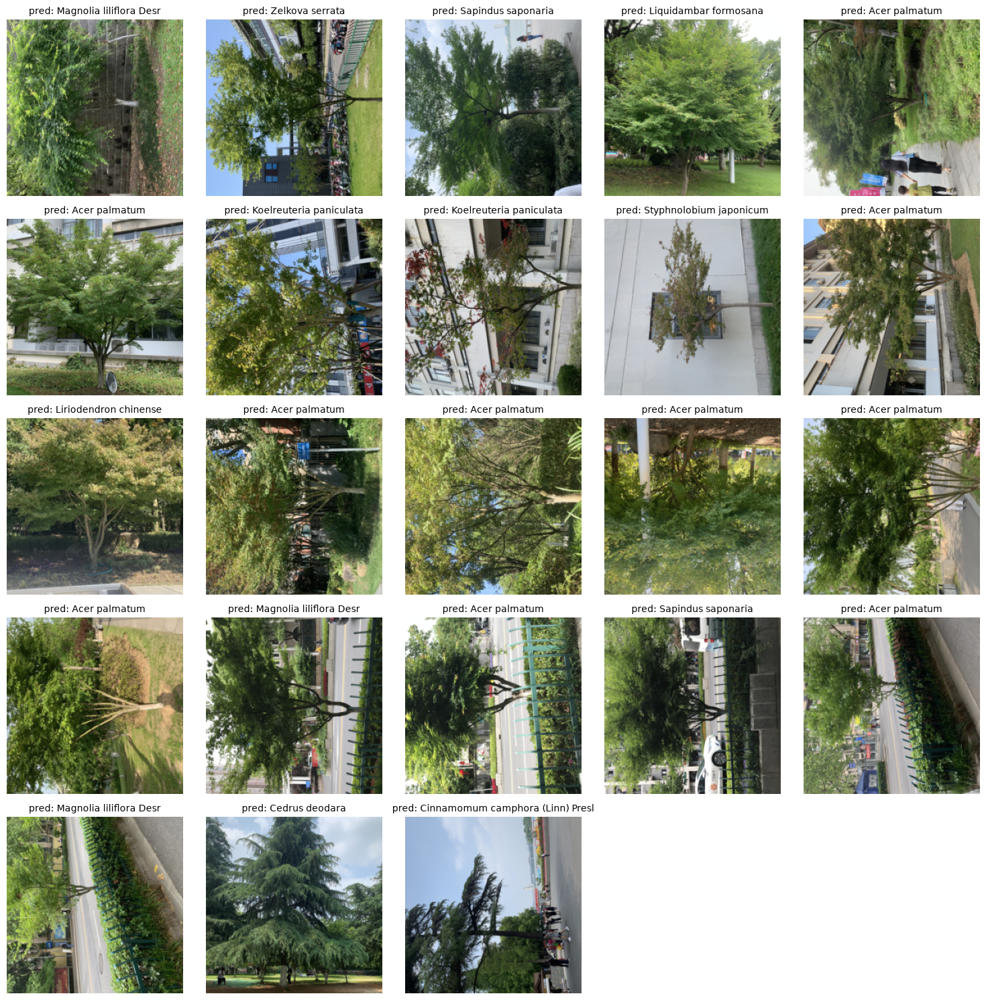

In [ ]:
visualize_model(model_conv, num_images=23, split='val')
# plt.ioff()
# plt.show()

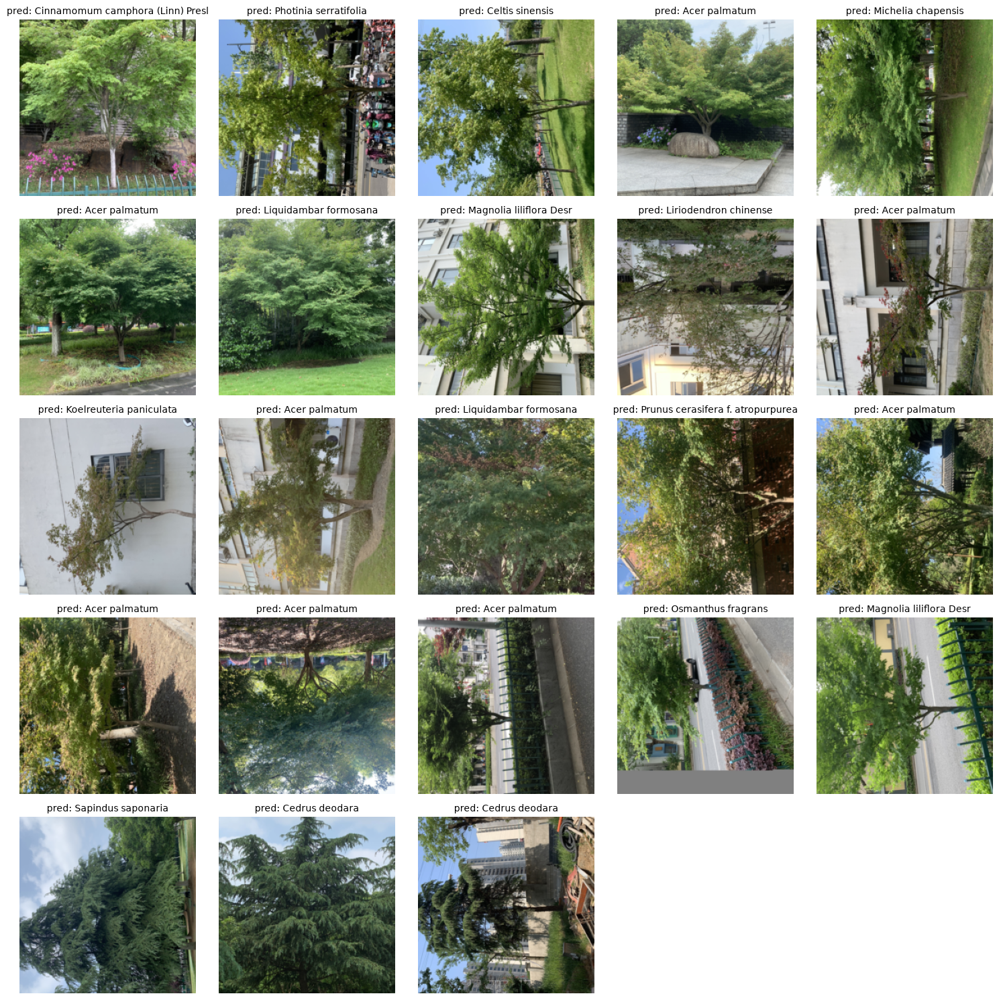

In [46]:
visualize_model(model_conv, num_images=23, split='test')

In [25]:
def visualize_model_predictions(model,img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[preds[0]]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)